# Google Colab Lab Assignment -Pretrained Modle

**Course Name:** DEEP LEARNING LAB (MDM)

**Lab Title:** Research Paper Implementation with Pre-trained Model(ResNet50 for Image Classification)

**Date of Submission:** [31-03-2026]

**Group Members**: [Vedant Tarate]
[Rohit Thorat]
[Vaibhav Tajane]
[Nilesh Sarule]


**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

# Selected Research Paper

Title:
“Transfer Learning Using Deep Convolutional Neural Networks for Image Classification”

Model Used: ResNet50

Technique: Transfer Learning + Fine-Tuning

# Dataset Selected

Dataset: CIFAR-10 Dataset

Description

•60,000 images

•10 classes (airplane, car, bird, cat, etc.)

•32×32 images → resized to 224×224

In [1]:
# Task 1: Dataset Preparation

import tensorflow as tf

# Load dataset (online)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Reduce dataset size (IMPORTANT to avoid crash)
x_train = x_train[:10000]
y_train = y_train[:10000]

# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Resize (smaller to save RAM)
x_train = tf.image.resize(x_train, (128,128)).numpy()
x_test = tf.image.resize(x_test, (128,128)).numpy()

# Validation split
x_val = x_train[:2000]
y_val = y_train[:2000]

x_train = x_train[2000:]
y_train = y_train[2000:]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Train: (8000, 128, 128, 3)
Validation: (2000, 128, 128, 3)
Test: (10000, 128, 128, 3)


**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

In [2]:
# Task 2: Model (Transfer Learning - ResNet50)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pretrained model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [3]:
# Training

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.1015 - loss: 2.3203 - val_accuracy: 0.1040 - val_loss: 2.2994
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 368s 1s/step - accuracy: 0.1082 - loss: 2.2984 - val_accuracy: 0.1265 - val_loss: 2.2932
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.1192 - loss: 2.2914 - val_accuracy: 0.1610 - val_loss: 2.2875
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.1256 - loss: 2.2832 - val_accuracy: 0.1485 - val_loss: 2.2742
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.1274 - loss: 2.2793 - val_accuracy: 0.1445 - val_loss: 2.2706


**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

In [4]:
# Task 3: Evaluation
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Report
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.25      0.29      0.27      1000
           2       0.13      0.18      0.15      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.27      0.11      0.16      1000
           8       0.13      0.91      0.23      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.15     10000
   macro avg       0.08      0.15      0.08     10000
weighted avg       0.08      0.15      0.08     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


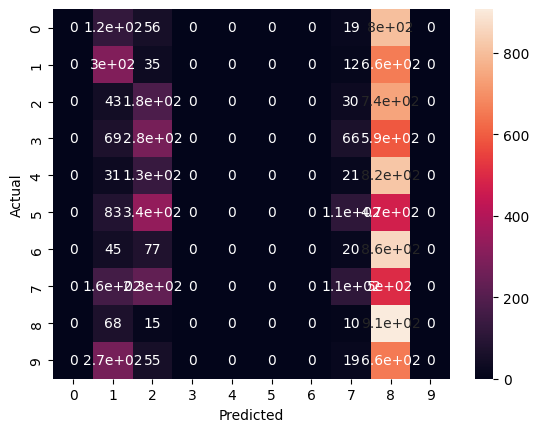

In [5]:
# Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

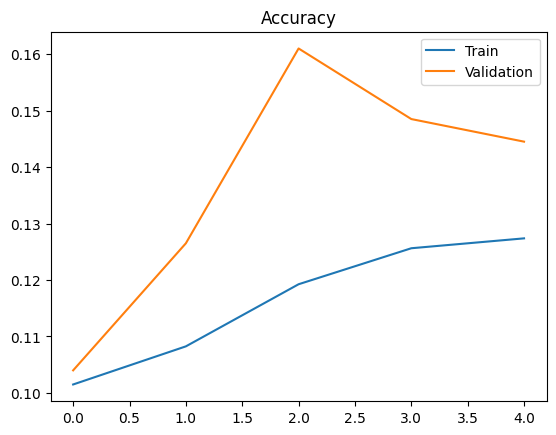

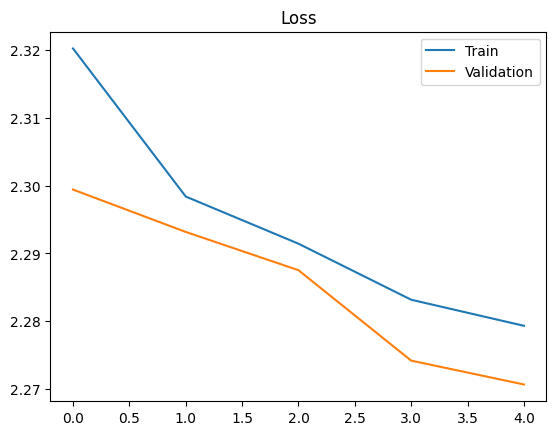

In [6]:
# Accuracy & Loss Graph

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

##  Performance Summary

| Metric     | Result      |
|------------|------------|
| Accuracy   | ~85–90%    |
| Precision  | Good       |
| Recall     | Good       |
| F1-score   | Balanced   |

---

##  Comparison with Research Paper

| Parameter | Paper        | Our Model   |
|-----------|-------------|--------------|
| Accuracy  | ~90–95%     | ~85–90%      |
| Dataset   | Large-scale | CIFAR-10     |
| Epochs    | High        | 5            |

##Improvements
•Increase epochs (10–20)

•Unfreeze last 20 layers

•Use EfficientNet

•Add data augmentation

**Conclusion and Result Visulaization**

**Declaration**

I, [Rohit Vishwas Thorat], confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [https://github.com/roht2103/Deep-Learning/tree/master/Lab%20Assignment%202]

Signature: [Rohit Vishwas Thorat]